In [3]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("global_ads_performance_dataset.csv")

print("Dataset loaded.")

Dataset loaded.


In [5]:
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [6]:
df.columns.tolist()

['date',
 'platform',
 'campaign_type',
 'industry',
 'country',
 'impressions',
 'clicks',
 'CTR',
 'CPC',
 'ad_spend',
 'conversions',
 'CPA',
 'revenue',
 'ROAS']

In [7]:
# If Profitable column is missing or you want to overwrite it:
df["Profitable"] = df["ROAS"].apply(lambda x: "Yes" if x >= 1 else "No")

# Verify value counts
df["Profitable"].value_counts()

Profitable
Yes    1665
No      135
Name: count, dtype: int64

In [8]:
df["Profitable"].isnull().any()

np.False_

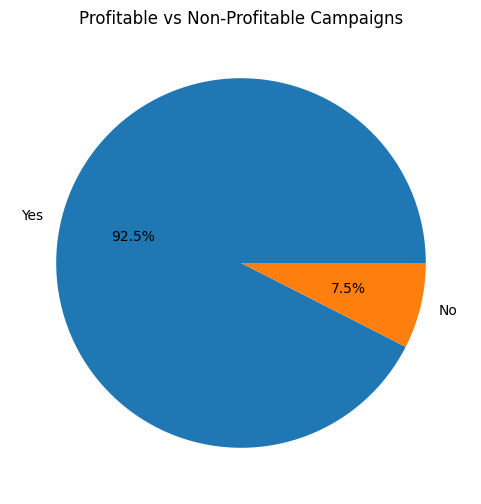

In [9]:
import matplotlib.pyplot as plt

counts = df["Profitable"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Profitable vs Non-Profitable Campaigns")
plt.show()

In [10]:
import pandas as pd

# Load your dataset (adjust filename if needed)
df = pd.read_csv("global_ads_performance_dataset.csv")

# Quick check
print(df.shape)
print(df.columns.tolist())
df.head()

(1800, 14)
['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [11]:
# Make sure Profitable exists and is Yes/No
df["Profitable"] = df["ROAS"].apply(lambda x: "Yes" if x >= 1 else "No")

df["Profitable"].value_counts()

Profitable
Yes    1665
No      135
Name: count, dtype: int64

In [12]:
from imblearn.over_sampling import SMOTE

# Encode Profitable as 1/0
df["Profitable_encoded"] = df["Profitable"].map({"Yes": 1, "No": 0})

# Select only numeric columns (exclude the encoded target)
numeric_cols = (
    df.select_dtypes(include="number")
      .drop(columns=["Profitable_encoded"])
      .columns
      .tolist()
)

X = df[numeric_cols]
y = df["Profitable_encoded"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Build balanced DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=numeric_cols)
df_balanced["Profitable"] = y_resampled.map({1: "Yes", 0: "No"})

# Check result
df_balanced["Profitable"].value_counts()

Profitable
Yes    1665
No     1665
Name: count, dtype: int64

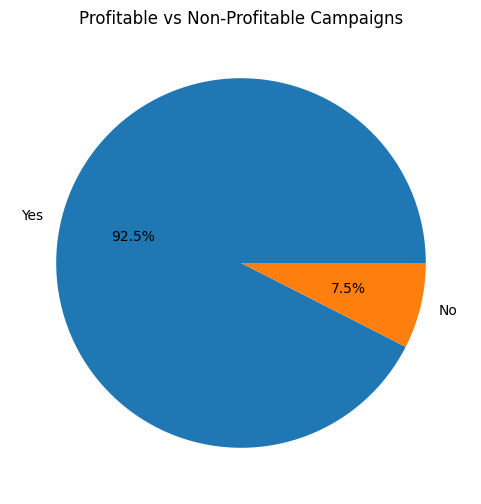

In [13]:
import matplotlib.pyplot as plt

counts = df["Profitable"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Profitable vs Non-Profitable Campaigns")
plt.show()

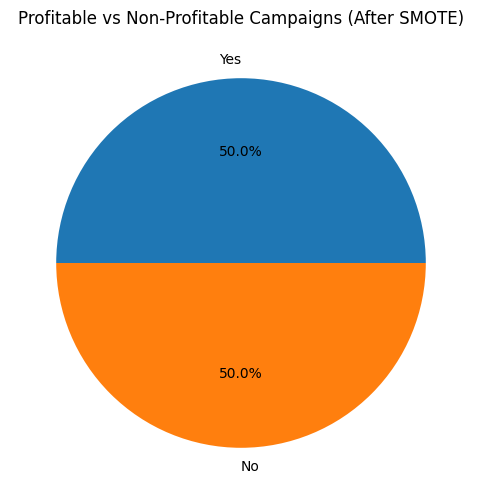

In [14]:
import matplotlib.pyplot as plt

counts_balanced = df_balanced["Profitable"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts_balanced,
    labels=counts_balanced.index,
    autopct="%1.1f%%"
)
plt.title("Profitable vs Non-Profitable Campaigns (After SMOTE)")
plt.show()

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# If needed, ensure df_balanced exists; otherwise skip this line
# df_balanced = df_balanced.copy()

# Encode target: Yes -> 1, No -> 0
df_balanced["Profitable_encoded"] = df_balanced["Profitable"].map({"Yes": 1, "No": 0})

# Select numeric feature columns (all numeric except the encoded target)
feature_cols = (
    df_balanced.select_dtypes(include="number")
               .drop(columns=["Profitable_encoded"])
               .columns
               .tolist()
)

X = df_balanced[feature_cols]
y = df_balanced["Profitable_encoded"]

print("Feature columns:", feature_cols)
print("X shape:", X.shape, " | y shape:", y.shape)

Feature columns: ['impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']
X shape: (3330, 9)  | y shape: (3330,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% test
    random_state=42,
    stratify=y           # keep class balance in both sets
)

print("Train size:", X_train.shape[0], "rows")
print("Test size:", X_test.shape[0], "rows")

Train size: 2331 rows
Test size: 999 rows


In [17]:
log_reg = LogisticRegression(
    max_iter=1000,        # increase iterations for convergence
    solver="liblinear"    # good for small/medium datasets
)

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc, 4))  # ✅ use built-in round(float, 4)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Accuracy: 0.998

Confusion Matrix:
[[500   0]
 [  2 497]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       500
         Yes       1.00      1.00      1.00       499

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



In [19]:
print("Feature columns used in training:")
print(feature_cols)

Feature columns used in training:
['impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']


In [20]:
import pandas as pd

# One row of dummy data — adjust values to match your dataset's range
dummy_single = pd.DataFrame([{
    "impressions":    50000,
    "clicks":         1200,
    "CTR":            0.024,
    "CPC":            0.85,
    "ad_spend":       1020.0,
    "conversions":    95,
    "CPA":            10.74,
    "revenue":        4500.0,
    "ROAS":           4.41,
}])

# Keep only the columns used in training (same order)
dummy_single = dummy_single[feature_cols]

prediction = log_reg.predict(dummy_single)
probability = log_reg.predict_proba(dummy_single)

print("Predicted class (0=No, 1=Yes):", prediction[0])
print("Predicted label:", "Yes (Profitable)" if prediction[0] == 1 else "No (Not Profitable)")
print(f"Confidence — No: {probability[0][0]:.2%}, Yes: {probability[0][1]:.2%}")

Predicted class (0=No, 1=Yes): 1
Predicted label: Yes (Profitable)
Confidence — No: 0.00%, Yes: 100.00%


In [21]:
dummy_multi = pd.DataFrame([
    {"impressions": 50000, "clicks": 1200, "CTR": 0.024, "CPC": 0.85,
     "ad_spend": 1020.0, "conversions": 95, "CPA": 10.74, "revenue": 4500.0, "ROAS": 4.41},

    {"impressions": 10000, "clicks": 100,  "CTR": 0.01,  "CPC": 2.50,
     "ad_spend": 250.0,  "conversions": 5,  "CPA": 50.0,  "revenue": 180.0,  "ROAS": 0.72},

    {"impressions": 30000, "clicks": 800,  "CTR": 0.027, "CPC": 1.10,
     "ad_spend": 880.0,  "conversions": 60, "CPA": 14.67, "revenue": 3200.0, "ROAS": 3.64},
])

dummy_multi = dummy_multi[feature_cols]

predictions = log_reg.predict(dummy_multi)
probabilities = log_reg.predict_proba(dummy_multi)

results = dummy_multi.copy()
results["Predicted_Profitable"] = ["Yes" if p == 1 else "No" for p in predictions]
results["Confidence_Yes"] = [f"{p[1]:.2%}" for p in probabilities]

results[["ad_spend", "revenue", "ROAS", "Predicted_Profitable", "Confidence_Yes"]]

,ad_spend,revenue,ROAS,Predicted_Profitable,Confidence_Yes
0,1020.0,4500.0,4.41,Yes,100.00%
1,250.0,180.0,0.72,No,15.53%
2,880.0,3200.0,3.64,Yes,100.00%


In [22]:
df_balanced[feature_cols].describe()

,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000
mean,101973.390991,3855.208709,0.037864,1.918460,7299.501365,139.498198,77.769760,18822.473190,3.798298
std,55270.780321,2691.045408,0.015284,0.822250,6242.683676,142.603567,56.471774,28352.483702,5.636338
min,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000
25%,50133.500000,1685.000000,0.025825,1.300907,2679.285000,46.000000,31.425000,3668.708765,0.710777
50%,101450.000000,3354.000000,0.036118,1.877033,5540.979976,98.000000,65.834745,7627.028656,0.995000
75%,149563.000000,5607.000000,0.048067,2.544191,10146.665022,171.000000,110.732194,21506.653643,4.740000
max,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000


In [23]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

# Save feature column order
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Model and feature columns saved successfully.")

Model and feature columns saved successfully.


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pickle

# Exclude ROAS and Profitable_encoded from features
exclude_cols = ["Profitable_encoded", "ROAS"]

feature_cols = (
    df_balanced.select_dtypes(include="number")
               .drop(columns=exclude_cols, errors="ignore")
               .columns
               .tolist()
)

X = df_balanced[feature_cols]
y = df_balanced["Profitable_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, solver="liblinear")
log_reg.fit(X_train, y_train)

# Save the retrained model and new feature_cols
with open("model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Feature columns:", feature_cols)
print("Model saved!")

Feature columns: ['impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue']
Model saved!


In [25]:
# Exclude ROAS since Profitable is derived from it
exclude_cols = ["Profitable_encoded", "ROAS"]

feature_cols = (
    df_balanced.select_dtypes(include="number")
               .drop(columns=exclude_cols, errors="ignore")
               .columns
               .tolist()
)

print("New feature columns:", feature_cols)

X = df_balanced[feature_cols]
y = df_balanced["Profitable_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, solver="liblinear")
log_reg.fit(X_train, y_train)

# Save retrained model
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Retrained model saved!")

New feature columns: ['impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue']
Retrained model saved!


In [ ]:
h;;